# 📊 Household Income — HIES (National, State, Distribution & Inequality)

## Dataset Overview

This notebook compiles multiple datasets from the Department of Statistics Malaysia Household Income and Expenditure Survey (HIES/HIS), Malaysia’s most authoritative source of household income distribution statistics.

The HIES is conducted every 2–3 years and captures detailed information on gross household income, expenditure patterns, poverty incidence, and income inequality. Unlike labour surveys that focus on individuals, HIES measures income at the **household level**, making it particularly suitable for evaluating living standards and long-term economic mobility.

This notebook integrates four related datasets:

1. **National household income trends**
2. **State-level household income and poverty indicators**
3. **Income distribution by percentile**
4. **Gini coefficient (income inequality measure)**

Together, these datasets provide a comprehensive picture of income growth, regional disparities, and structural inequality in Malaysia from 1970 to 2022.

---

## Data Sources

| Dataset                   | Description                                              | Parquet URL                                                 |
| ------------------------- | -------------------------------------------------------- | ----------------------------------------------------------- |
| National household income | Mean & median monthly household income (Malaysia total)  | `storage.dosm.gov.my/hies/hh_income.parquet`                |
| Household income by state | Income, expenditure, poverty & inequality at state level | `storage.dosm.gov.my/hies/hh_income_state.parquet`          |
| Income by percentile      | Distribution of income across population percentiles     | `storage.dosm.gov.my/hies/hies_malaysia_percentile.parquet` |
| Gini coefficient          | National income inequality indicator                     | `storage.dosm.gov.my/hies/hh_inequality.parquet`            |

**Publisher:** Department of Statistics Malaysia
**License:** CC BY 4.0
**Coverage:** 1970 – 2022 (Survey years: 1970, 1974, 1976, 1979, 1982, 1984, 1987, 1989, 1992, 1995, 1997, 1999, 2002, 2004, 2007, 2009, 2012, 2014, 2016, 2019, 2022)

---

## Column Descriptions — National Household Income
link: https://open.dosm.gov.my/data-catalogue/hh_income 

| Column          | Description                                |
| --------------- | ------------------------------------------ |
| `date`          | Survey year                                |
| `income_mean`   | Mean gross monthly household income (RM)   |
| `income_median` | Median gross monthly household income (RM) |

**Note:**
The difference between mean and median income provides insight into income skewness. A widening gap suggests rising inequality.

---

## Column Descriptions — State-Level Household Income
link: https://open.dosm.gov.my/data-catalogue/hh_income_state

| Column             | Description                             |
| ------------------ | --------------------------------------- |
| `date`             | Survey year                             |
| `state`            | Malaysian state                         |
| `income_mean`      | Mean monthly household income (RM)      |
| `income_median`    | Median monthly household income (RM)    |
| `expenditure_mean` | Mean monthly household expenditure (RM) |
| `gini`             | State-level Gini coefficient            |
| `poverty`          | Poverty incidence rate (%)              |

This dataset enables analysis of:

* Regional income disparity
* Cost-of-living differences
* Poverty reduction progress
* State-level inequality

---

## Column Descriptions — Income Distribution (Percentiles)
link: https://open.dosm.gov.my/data-catalogue/hies_malaysia_percentile

| Column       | Description                      |
| ------------ | -------------------------------- |
| `date`       | Survey year                      |
| `percentile` | Income percentile group          |
| `income`     | Average income within percentile |

This dataset allows deeper distributional analysis beyond mean/median values and is useful for studying income mobility and structural inequality.

---

## Column Descriptions — Gini Coefficient
link: https://open.dosm.gov.my/data-catalogue/hh_inequality

| Column | Description                                                                     |
| ------ | ------------------------------------------------------------------------------- |
| `date` | Survey year                                                                     |
| `gini` | National income inequality index (0 = perfect equality, 1 = perfect inequality) |

The Gini coefficient measures the overall dispersion of income and is widely used in international inequality comparisons.

---

# 🎯 Relevance to EduNilai

These datasets form the **macroeconomic foundation** of the EduNilai ROI framework.

Specifically:

* **Baseline comparison:**
  National median household income represents the counterfactual earnings benchmark — what a typical Malaysian household earns regardless of tertiary qualification.

* **Geographic inequality dimension:**
  State-level income differences help evaluate whether higher education yields consistent returns across regions.

* **Income distribution impact:**
  Percentile data enables analysis of whether graduates move into higher income brackets over time.

* **Inequality tracking:**
  The Gini trend provides macro evidence on whether expansion of higher education correlates with improved income equality.

Together, these indicators allow EduNilai to contextualise graduate salary outcomes within broader national income trends and structural inequality patterns.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def load_dosm_parquet(url):
    """
    Load DOSM parquet dataset and convert date column if available.
    """
    df = pd.read_parquet(url)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    return df


# URLs
URLS = {
    "national": "https://storage.dosm.gov.my/hies/hh_income.parquet",
    "state": "https://storage.dosm.gov.my/hies/hh_income_state.parquet",
    "percentiles": "https://storage.dosm.gov.my/hies/hies_malaysia_percentile.parquet",
    "gini": "https://storage.dosm.gov.my/hies/hh_inequality.parquet"
}

# Load all datasets
datasets = {name: load_dosm_parquet(url) for name, url in URLS.items()}

# Assign to variables (optional)
df_national = datasets["national"]
df_state = datasets["state"]
df_percentiles = datasets["percentiles"]
df_gini = datasets["gini"]

# Quick check
for name, df in datasets.items():
    print(f"{name.capitalize():12}: {df.shape} | cols: {list(df.columns)}")

National    : (21, 3) | cols: ['date', 'income_mean', 'income_median']
State       : (303, 4) | cols: ['state', 'date', 'income_mean', 'income_median']
Percentiles : (1200, 4) | cols: ['date', 'percentile', 'variable', 'income']
Gini        : (20, 2) | cols: ['date', 'gini']


In [5]:
# Filter national to 2009 onwards (HIES years available)
df_nat_2010 = df_national[df_national['date'].dt.year >= 2010].copy()
print("National income (2010 onwards):")
print(df_nat_2010.to_string(index=False))

National income (2010 onwards):
      date  income_mean  income_median
2012-01-01         5000           3626
2014-01-01         6141           4585
2016-01-01         6958           5228
2019-01-01         7901           5873
2020-01-01         7089           5209
2022-01-01         8479           6338


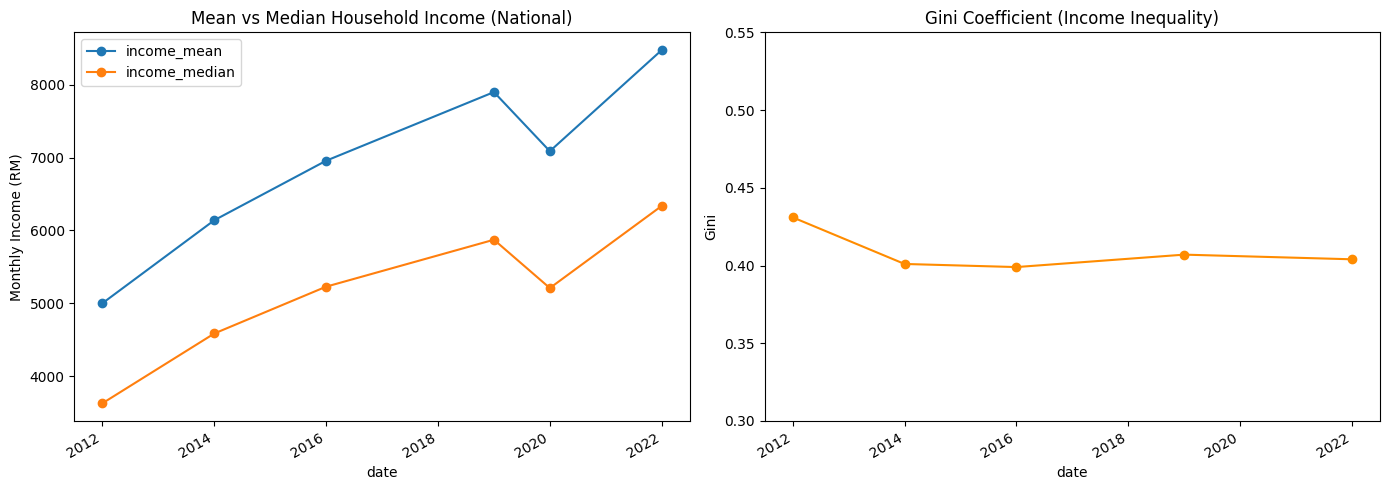

In [6]:
# Plot: national median income trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_nat_2010.set_index('date')[['income_mean', 'income_median']].plot(ax=axes[0], marker='o')
axes[0].set_title('Mean vs Median Household Income (National)')
axes[0].set_ylabel('Monthly Income (RM)')

# Gini trend
df_gini_2010 = df_gini[df_gini['date'].dt.year >= 2010]
if 'gini' in df_gini_2010.columns:
    df_gini_2010.set_index('date')['gini'].plot(ax=axes[1], marker='o', color='darkorange')
    axes[1].set_title('Gini Coefficient (Income Inequality)')
    axes[1].set_ylabel('Gini')
    axes[1].set_ylim(0.3, 0.55)

plt.tight_layout()
plt.show()

In [8]:
# check df before exporting to csv
df_nat_2010

,date,income_mean,income_median
15,2012-01-01,5000,3626
16,2014-01-01,6141,4585
17,2016-01-01,6958,5228
18,2019-01-01,7901,5873
19,2020-01-01,7089,5209
20,2022-01-01,8479,6338


In [9]:
df_state_2010 = df_state[df_state['date'].dt.year >= 2010]
df_state_2010

,state,date,income_mean,income_median
15,Johor,2012-01-01,4658,3650
16,Johor,2014-01-01,6207,5197
17,Johor,2016-01-01,6928,5652
18,Johor,2019-01-01,8013,6427
19,Johor,2020-01-01,7264,5690
...,...,...,...,...
298,W.P. Putrajaya,2014-01-01,10401,7512
299,W.P. Putrajaya,2016-01-01,11555,8275
300,W.P. Putrajaya,2019-01-01,12840,9983
301,W.P. Putrajaya,2020-01-01,12322,9743


In [10]:
df_percentiles_2010 = df_percentiles[df_percentiles['date'].dt.year >= 2010]
df_percentiles_2010

,date,percentile,variable,income
0,2024-01-01,1,mean,1334.0
1,2024-01-01,2,mean,1683.0
2,2024-01-01,3,mean,1906.0
3,2024-01-01,4,mean,2085.0
4,2024-01-01,5,mean,2230.0
...,...,...,...,...
1195,2019-01-01,96,maximum,21563.0
1196,2019-01-01,97,maximum,24062.0
1197,2019-01-01,98,maximum,28057.0
1198,2019-01-01,99,maximum,36615.0


In [11]:
df_gini_2010 = df_gini[df_gini['date'].dt.year >= 2010]
df_gini_2010

,date,gini
15,2012-01-01,0.431
16,2014-01-01,0.401
17,2016-01-01,0.399
18,2019-01-01,0.407
19,2022-01-01,0.404


In [12]:
os.makedirs('../data/demographic', exist_ok=True)

df_nat_2010.to_csv('../data/demographic/hh_income_national.csv', index=False, encoding='utf-8')
df_state_2010.to_csv('../data/demographic/hh_income_state.csv', index=False, encoding='utf-8')
df_percentiles_2010.to_csv('../data/demographic/hh_income_percentiles.csv', index=False, encoding='utf-8')
df_gini_2010.to_csv('../data/demographic/income_inequality_gini.csv', index=False, encoding='utf-8')

print("Saved:")
print("  ../data/demographic/hh_income_national.csv")
print("  ../data/demographic/hh_income_state.csv")
print("  ../data/demographic/hh_income_percentiles.csv")
print("  ../data/demographic/income_inequality_gini.csv")

Saved:
  ../data/demographic/hh_income_national.csv
  ../data/demographic/hh_income_state.csv
  ../data/demographic/hh_income_percentiles.csv
  ../data/demographic/income_inequality_gini.csv
